# FFSP products for every realization

This notebook verifies the complete information flow: the Fortran kernel returns kinematics, quality metrics, the full source time function (STF), the synthetic spectrum, and octave-averaged spectra for every realization; Python selects any realization without recomputation; HDF5 preserves the same structure.

In [1]:
from pathlib import Path
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve().parents[2]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from shakermaker.crustmodel import CrustModel
from shakermaker.ffspsource import FFSPSource

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

In [2]:
crust = CrustModel(4)
crust.add_layer(0.200, 1.32, 0.75, 2.40, 1000.0, 1000.0)
crust.add_layer(0.800, 2.75, 1.57, 2.50, 1000.0, 1000.0)
crust.add_layer(14.500, 5.50, 3.14, 2.50, 1000.0, 1000.0)
crust.add_layer(0.000, 7.00, 4.00, 2.67, 1000.0, 1000.0)

source = FFSPSource(
    id_sf_type=8, freq_min=0.01, freq_max=24.0,
    fault_length=30.0, fault_width=16.0,
    x_hypc=15.0, y_hypc=8.0, depth_hypc=8.0,
    xref_hypc=0.0, yref_hypc=0.0,
    magnitude=6.0, fc_main_1=0.09, fc_main_2=3.0,
    rv_avg=3.0, ratio_rise=0.3,
    strike=358.0, dip=40.0, rake=113.0,
    pdip_max=15.0, prake_max=30.0,
    nsubx=16, nsuby=8, nb_taper_trbl=[5, 5, 5, 5],
    seeds=[52, 448, 4446], id_ran1=1, id_ran2=3,
    angle_north_to_x=0.0, is_moment=3, crust_model=crust,
    output_name="FFSP_ALL_PRODUCTS", verbose=False,
)
source.run()

{'nseg': 1,
 'npts': 128,
 'realization_id': 2,
 'x': array([-15204.739   , -15151.2705  , -15097.801   , -15044.332   ,
        -14990.863   , -14937.394   , -14883.925   , -14830.455   ,
        -13330.881   , -13277.412   , -13223.942   , -13170.474   ,
        -13117.004   , -13063.535   , -13010.066   , -12956.597   ,
        -11457.023   , -11403.555   , -11350.085   , -11296.616   ,
        -11243.146   , -11189.677   , -11136.209   , -11082.739   ,
         -9583.166   ,  -9529.697   ,  -9476.228   ,  -9422.759   ,
         -9369.289   ,  -9315.819   ,  -9262.351   ,  -9208.882   ,
         -7709.3086  ,  -7655.8394  ,  -7602.3696  ,  -7548.9004  ,
         -7495.4316  ,  -7441.9624  ,  -7388.493   ,  -7335.0234  ,
         -5835.4507  ,  -5781.9814  ,  -5728.5117  ,  -5675.0425  ,
         -5621.573   ,  -5568.1045  ,  -5514.6353  ,  -5461.1655  ,
         -3961.593   ,  -3908.1235  ,  -3854.6543  ,  -3801.1848  ,
         -3747.7158  ,  -3694.2466  ,  -3640.777   ,  -3587.307

In [3]:
products = source.all_realizations
expected_shapes = {
    "kinematics": products["slip"].shape,
    "stf": products["stf_time"]["stf"].shape,
    "spectrum": products["spectrum"]["moment_rate_synth"].shape,
    "octaves": products["spectrum_octave"]["logmean_synth"].shape,
}
assert expected_shapes == {
    "kinematics": (128, 3),
    "stf": (131072, 3),
    "spectrum": (65536, 3),
    "octaves": (16, 3),
}
expected_shapes

{'kinematics': (128, 3),
 'stf': (131072, 3),
 'spectrum': (65536, 3),
 'octaves': (16, 3)}

In [4]:
best_index = int(np.argmin(source.source_stats["source_score"]["pdf"]))
source.set_active_realization(0)
selected = source.subfaults
np.testing.assert_array_equal(
    selected["spectrum"]["moment_rate_synth"],
    products["spectrum"]["moment_rate_synth"][:, 0],
)
source.subfaults = source.best_realization
{"best_index": best_index, "best_realization_id": source.subfaults["realization_id"]}

{'best_index': 1, 'best_realization_id': 2}

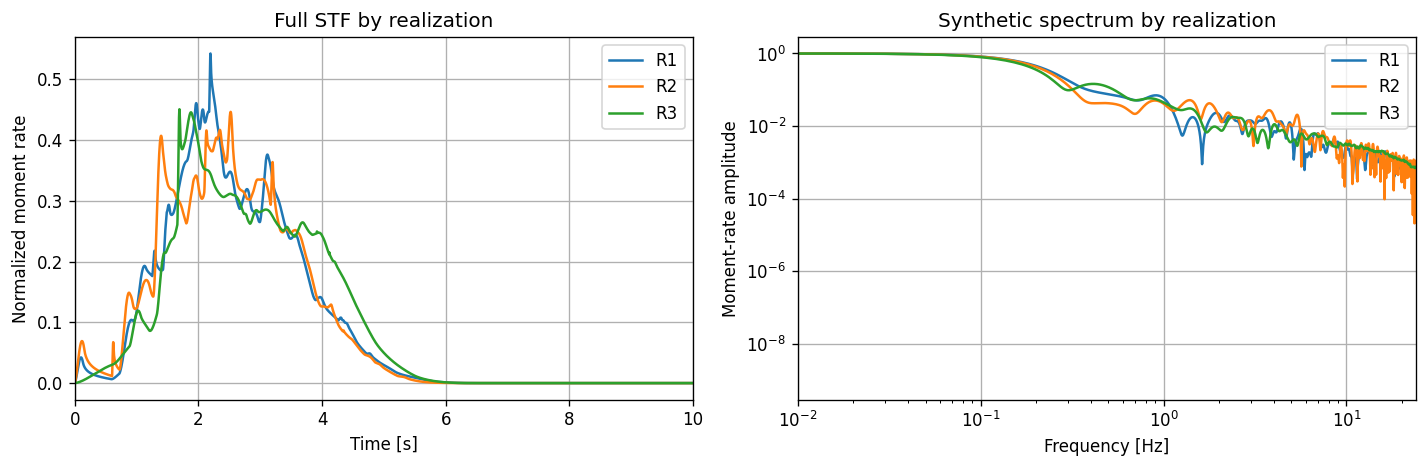

In [5]:
time = products["stf_time"]["time"]
frequency = products["spectrum"]["freq"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for index, realization_id in enumerate(products["realization_id"]):
    axes[0].plot(time, products["stf_time"]["stf"][:, index], label=f"R{realization_id}")
    axes[1].loglog(frequency, products["spectrum"]["moment_rate_synth"][:, index], label=f"R{realization_id}")
axes[0].set(xlabel="Time [s]", ylabel="Normalized moment rate", xlim=(0, 10), title="Full STF by realization")
axes[1].set(xlabel="Frequency [Hz]", ylabel="Moment-rate amplitude", xlim=(0.01, 24), title="Synthetic spectrum by realization")
for axis in axes:
    axis.legend()
fig.tight_layout()

In [6]:
with tempfile.TemporaryDirectory() as temp_dir:
    h5_path = Path(temp_dir) / "ffsp_all_products.h5"
    source.write_hdf5(str(h5_path))
    loaded = FFSPSource.from_hdf5(str(h5_path))
    for index in range(3):
        original = source.get_realization(index)
        restored = loaded.get_realization(index)
        np.testing.assert_array_equal(original["stf_time"]["stf"], restored["stf_time"]["stf"])
        np.testing.assert_array_equal(original["spectrum"]["moment_rate_synth"], restored["spectrum"]["moment_rate_synth"])

print("HDF5 round-trip passed for all realizations.")

Writing HDF5: C:\Users\ppala\AppData\Local\Temp\tmp97zwhv6n\ffsp_all_products.h5
[OK] HDF5 saved

Loading HDF5: C:\Users\ppala\AppData\Local\Temp\tmp97zwhv6n\ffsp_all_products.h5
HDF5 loaded
Best realization activated

[OK] HDF5 loaded

HDF5 round-trip passed for all realizations.
